In [91]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

In [92]:
df = pd.read_csv('/Users/jonbeshahmadzai/Desktop/becode_projects/Immovlan-Data-Analysis-/Data/cleaned/immovlan_dataset_cleaned.csv')

df.head()

,Zip Code,Municipality,Type of property,Subtype of property,Price,Type of sale,Number of rooms,Living Area,Fully equipped kitchen,Furnished,Terrace,Terrace Area,Garden,Garden Area,Surface of the land,Number of facades,Swimming pool,State of the building,price_per_m2,Region,building_state_encoded
0,1000,Brussels,Apartment,Apartment,365000.0,for sale,2.0,NaN,0.0,1.0,1.0,NaN,0.0,0.0,NaN,2.0,0.0,NaN,NaN,Brussels,NaN
1,3070,Kortenberg,Apartment,Apartment,349000.0,for sale,2.0,79.0,0.0,0.0,1.0,NaN,0.0,0.0,NaN,NaN,0.0,Normal,4417.721519,Flanders,5.0
2,4140,Sprimont,House,Residence,175000.0,for sale,2.0,75.0,0.0,0.0,0.0,0.0,1.0,NaN,46.0,3.0,0.0,Normal,2333.333333,Wallonia,5.0
3,1325,Chaumont Gistoux,House,Villa,783045.0,for sale,3.0,335.0,0.0,0.0,0.0,0.0,1.0,NaN,4500.0,4.0,0.0,New,2337.447761,Wallonia,9.0
4,8890,Moorslede,House,Residence,389000.0,for sale,4.0,220.0,0.0,0.0,1.0,29.0,1.0,NaN,411.0,2.0,0.0,NaN,1768.181818,Flanders,NaN


In [93]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21228 entries, 0 to 21227
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Zip Code                21228 non-null  int64  
 1   Municipality            21228 non-null  str    
 2   Type of property        21228 non-null  str    
 3   Subtype of property     21228 non-null  str    
 4   Price                   21228 non-null  float64
 5   Type of sale            21228 non-null  str    
 6   Number of rooms         20750 non-null  float64
 7   Living Area             19843 non-null  float64
 8   Fully equipped kitchen  21228 non-null  float64
 9   Furnished               21228 non-null  float64
 10  Terrace                 21228 non-null  float64
 11  Terrace Area            14019 non-null  float64
 12  Garden                  21228 non-null  float64
 13  Garden Area             13546 non-null  float64
 14  Surface of the land     11316 non-null  float64
 

In [94]:
df.describe()

,Zip Code,Price,Number of rooms,Living Area,Fully equipped kitchen,Furnished,Terrace,Terrace Area,Garden,Garden Area,Surface of the land,Number of facades,Swimming pool,price_per_m2,building_state_encoded
count,21228.000000,2.122800e+04,20750.000000,19843.000000,21228.000000,21228.000000,21228.000000,14019.000000,21228.000000,13546.000000,11316.000000,16350.000000,21228.000000,19843.000000,16489.000000
mean,4633.975127,4.237646e+05,3.055084,171.938719,0.133173,0.028971,0.729508,15.209715,0.587479,184.614868,1271.694680,2.838287,0.034294,2728.067409,6.154345
std,2892.345754,4.564318e+05,2.044708,146.760959,0.339770,0.167729,0.444224,24.541420,0.492300,504.425417,4203.289878,0.848137,0.181988,1455.185085,2.044065
min,1000.000000,1.500000e+04,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,1.000000,0.000000,116.279070,1.000000
25%,1760.000000,2.250000e+05,2.000000,97.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,240.000000,2.000000,0.000000,1809.917355,5.000000
50%,4101.000000,3.400000e+05,3.000000,142.000000,0.000000,0.000000,1.000000,7.000000,1.000000,0.000000,508.000000,3.000000,0.000000,2520.202020,5.000000
75%,7140.000000,4.950000e+05,4.000000,200.000000,0.000000,0.000000,1.000000,20.000000,1.000000,100.000000,1056.000000,4.000000,0.000000,3328.195429,8.000000
max,9992.000000,2.600000e+07,100.000000,5000.000000,1.000000,1.000000,1.000000,300.000000,1.000000,5000.000000,178367.000000,4.000000,1.000000,38117.647059,9.000000


In [95]:
missing_values = df.isna().sum()
missing_values.sort_values(ascending=False)

Surface of the land       9912
Garden Area               7682
Terrace Area              7209
Number of facades         4878
State of the building     4739
building_state_encoded    4739
price_per_m2              1385
Living Area               1385
Number of rooms            478
Zip Code                     0
Subtype of property          0
Type of property             0
Municipality                 0
Price                        0
Garden                       0
Furnished                    0
Fully equipped kitchen       0
Type of sale                 0
Terrace                      0
Swimming pool                0
Region                       0
dtype: int64

Some variables such as Garden Area and Terrace Area contain missing values because they depend on other features. For example, if a property does not have a garden or terrace, the corresponding area cannot exist, so the value is set to missing or it wasnt there when scrapping. 

Other variables such as Surface of the land, Number of facades, or State of the building contain missing values because the information was not provided in the original listings or could not be captured during the scraping process. Missing values of this type are common in real estate datasets and were therefore kept as missing rather than being artificially imputed.

Now lets dive in to the analysis part:

How many rows and columns?

What is the correlation between the variables and the price? (Why might that be?)

How are variables correlated to each other? (Why?)

Which variables have the greatest influence on the price?

Which variables have the least influence on the price?

How many qualitative and quantitative variables are there? How would you transform these values into numerical values?

Percentage of missing values per column?

### 1. How many rows and columns?


The dataset contains 21,228 observations (rows) and 21 variables (columns).
Each row represents a property listing collected from Immovlan, while the columns describe various property characteristics such as price, living area, number of rooms, presence of a terrace or garden, and geographic location.

In [96]:
df.shape

#df.shape[0]
#df.shape[1]

(21228, 21)

### 2. percentage of missing values per column 

In [97]:
missing_pct = (df.isna().sum() / len(df)) * 100
missing_pct = missing_pct.sort_values(ascending=False)
missing_pct

Surface of the land       46.693047
Garden Area               36.188054
Terrace Area              33.959864
Number of facades         22.979084
State of the building     22.324289
building_state_encoded    22.324289
price_per_m2               6.524402
Living Area                6.524402
Number of rooms            2.251743
Zip Code                   0.000000
Subtype of property        0.000000
Type of property           0.000000
Municipality               0.000000
Price                      0.000000
Garden                     0.000000
Furnished                  0.000000
Fully equipped kitchen     0.000000
Type of sale               0.000000
Terrace                    0.000000
Swimming pool              0.000000
Region                     0.000000
dtype: float64

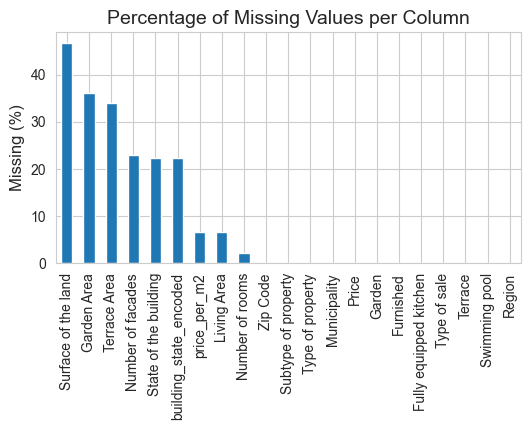

In [98]:
plt.figure(figsize=(6,3))
missing_pct.plot(kind="bar")
plt.title("Percentage of Missing Values per Column")
plt.ylabel("Missing (%)")
plt.show()

### 2. Percentage of Missing Values per Column

The bar chart shows the proportion of missing values for each variable in the dataset.

The highest percentage of missing values appears in variables such as **Garden Area**, **Terrace Area**, and **Surface of the land**. This occurs mainly because these attributes only apply to certain types of properties. For example, apartments often do not have a garden or a terrace, so these values are naturally missing.

Other variables such as **Number of facades** or **State of the building** may contain missing values because the information was not provided in the original listings or could not be captured during the scraping process.

Missing values were therefore kept as they are rather than artificially imputed, since their absence often reflects real characteristics of the property listings.

### 3. How are variables correlated to each other? (Why?)


In [99]:
num_df = df.select_dtypes(include='number').drop(columns=['Zip Code']).corr()
num_df = num_df.corr()
num_df

,Price,Number of rooms,Living Area,Fully equipped kitchen,Furnished,Terrace,Terrace Area,Garden,Garden Area,Surface of the land,Number of facades,Swimming pool,price_per_m2,building_state_encoded
Price,1.000000,0.654960,0.690948,-0.390410,-0.289641,-0.226147,-0.011169,-0.114071,-0.039593,0.304799,0.004809,0.013278,0.211932,0.092035
Number of rooms,0.654960,1.000000,0.930255,-0.144806,-0.286764,-0.260576,-0.008066,0.300959,0.289963,0.250165,0.241724,0.040591,-0.510873,-0.368857
Living Area,0.690948,0.930255,1.000000,-0.185923,-0.336449,-0.252470,0.096615,0.311923,0.381410,0.383718,0.317481,0.148533,-0.527155,-0.378050
Fully equipped kitchen,-0.390410,-0.144806,-0.185923,1.000000,-0.074029,0.067215,-0.029331,-0.057864,-0.074139,-0.223956,-0.217663,-0.167036,-0.277814,-0.350002
Furnished,-0.289641,-0.286764,-0.336449,-0.074029,1.000000,-0.118357,-0.247824,-0.357987,-0.359796,-0.183534,-0.273173,-0.132316,0.143172,-0.036980
Terrace,-0.226147,-0.260576,-0.252470,0.067215,-0.118357,1.000000,0.674101,-0.046403,-0.074016,-0.252971,-0.303737,-0.075258,0.078641,-0.052521
Terrace Area,-0.011169,-0.008066,0.096615,-0.029331,-0.247824,0.674101,1.000000,0.108491,0.305925,0.005385,0.025098,0.207666,-0.106134,-0.206184
Garden,-0.114071,0.300959,0.311923,-0.057864,-0.357987,-0.046403,0.108491,1.000000,0.711088,-0.003114,0.509440,0.099139,-0.630538,-0.388642
Garden Area,-0.039593,0.289963,0.381410,-0.074139,-0.359796,-0.074016,0.305925,0.711088,1.000000,0.368900,0.643192,0.319261,-0.572468,-0.510320
Surface of the land,0.304799,0.250165,0.383718,-0.223956,-0.183534,-0.252971,0.005385,-0.003114,0.368900,1.000000,0.255033,0.090503,-0.089098,-0.285583


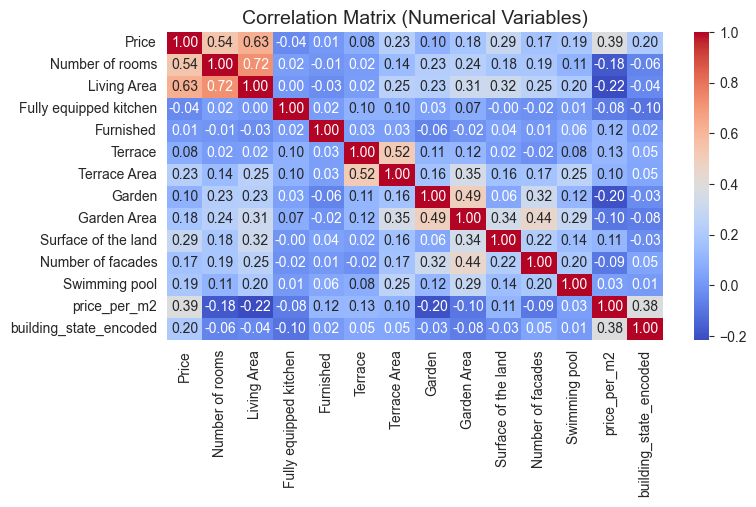

In [100]:
plt.figure(figsize=(8,4))
sns.heatmap(df.select_dtypes(include='number').drop(columns=['Zip Code']).corr(),
            cmap='coolwarm',
            annot=True,
            fmt=".2f")

plt.title("Correlation Matrix (Numerical Variables)")
plt.show()


### Correlation Matrix (Numerical Variables)

The correlation matrix shows the relationships between all numerical variables in the dataset. It helps identify how different features are related to each other and which variables move together.

Several strong correlations can be observed. The strongest relationship is between **Living Area and Number of rooms (0.72)**, which is expected since larger properties generally contain more rooms. **Garden Area and Surface of the land (0.34)** also show a positive correlation, indicating that properties with larger land surfaces tend to have larger gardens.

Another notable relationship is between **Garden and Garden Area (0.49)**, which makes logical sense because properties that have a garden tend to have measurable garden space.

When looking specifically at **Price**, the strongest relationships appear with **Living Area (0.63)** and **Number of rooms (0.54)**, suggesting that larger homes with more rooms tend to be more expensive.

Other variables such as **Terrace Area**, **Swimming pool**, and **Number of facades** show weaker positive correlations with price, meaning they may contribute to property value but are less influential than property size.

Overall, the matrix suggests that **property size (living area and number of rooms)** and **land characteristics (garden area and land surface)** are the variables most strongly related to each other and to property prices.


### 4. What is the correlation between the variables and the price? why might that be ? 

In [101]:
corr_with_price = df.drop(columns=['Zip Code']).select_dtypes(include='number').corr()['Price'].sort_values(ascending=False)

corr_with_price


Price                     1.000000
Living Area               0.626633
Number of rooms           0.539619
price_per_m2              0.387046
Surface of the land       0.293757
Terrace Area              0.232042
building_state_encoded    0.201828
Swimming pool             0.186064
Garden Area               0.178569
Number of facades         0.168203
Garden                    0.097233
Terrace                   0.082836
Furnished                 0.005783
Fully equipped kitchen   -0.037734
Name: Price, dtype: float64

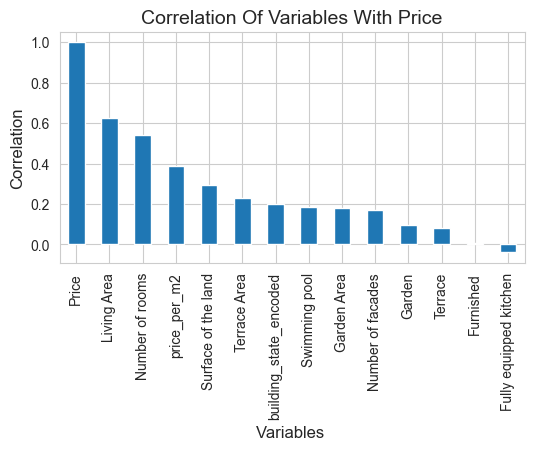

In [102]:
plt.figure(figsize=(6,3))
corr_with_price.plot(kind='bar')
plt.title('Correlation Of Variables With Price')
plt.ylabel('Correlation')
plt.xlabel('Variables ')
plt.show()

### 4. Correlation Between the Variables and Price

The correlation analysis shows how strongly each numerical variable is related to property price.
The strongest positive correlation with **Price** is observed for **Living Area (≈0.63)**, followed by **Number of rooms (≈0.54)** and **price per m² (≈0.39)**. This indicates that larger properties with more rooms and a higher price per square meter tend to be more expensive.
Other variables such as **Surface of the land (≈0.29)**, **Terrace Area (≈0.23)**, **building state (≈0.20)**, **Swimming pool (≈0.19)**, and **Garden Area (≈0.18)** also show positive correlations with price, but their influence is weaker compared to the size of the property.
Variables such as **Garden**, **Terrace**, **Furnished**, and **Fully equipped kitchen** show very weak correlations with price. This suggests that optional amenities have less influence on property price compared to structural characteristics such as size and land surface.
Overall, the analysis confirms that **property size is the main driver of price in this dataset**.

### 5. which variable has the greatest influence on the price ? 

In [103]:
corr_with_price.drop("Price").head(10)

Living Area               0.626633
Number of rooms           0.539619
price_per_m2              0.387046
Surface of the land       0.293757
Terrace Area              0.232042
building_state_encoded    0.201828
Swimming pool             0.186064
Garden Area               0.178569
Number of facades         0.168203
Garden                    0.097233
Name: Price, dtype: float64

### 5. Which Variable Has the Greatest Influence on Price?

Based on the correlation analysis, **Living Area** has the strongest influence on property price. It shows the highest positive correlation with price (approximately **0.63**).
This result is expected in real estate markets because the size of a property is one of the main factors determining its value. Larger properties typically offer more usable space, making them more attractive and therefore more expensive.
Other important variables include **Number of rooms**, **price per m²**, and **Surface of the land**, which are also related to the overall size and value of a property.

### 6. which variable has the least influence on the price ? 

In [104]:
corr_with_price.drop("Price").tail(8)

building_state_encoded    0.201828
Swimming pool             0.186064
Garden Area               0.178569
Number of facades         0.168203
Garden                    0.097233
Terrace                   0.082836
Furnished                 0.005783
Fully equipped kitchen   -0.037734
Name: Price, dtype: float64

### 6. Which Variable Has the Least Influence on Price?

The variables with the weakest correlation with price are **Furnished**, **Fully equipped kitchen**, **Terrace**, and **Garden**.
These features represent optional amenities rather than structural characteristics of the property. While they may improve the attractiveness of a listing, they do not significantly influence the overall property value compared to variables such as living area, number of rooms, or land size.
This suggests that **structural characteristics of a property play a much larger role in determining price than optional amenities**.

### 7. How many qualitative and quantitative variables are there? How would you transform these values into numerical values?

In [105]:
qualitative_col = df.select_dtypes(include="number").columns
len(qualitative_col)

15

In [106]:
quantitative_col = df.select_dtypes(exclude="number").columns
len(quantitative_col)

6

Transforming it into numerical values cause now they are strings

In [107]:
#df_encoded = pd.get_dummies(df, columns=["Type of property", "Subtype of property", "Type of sale", "State of the building", "Municipality"], drop_first=True)
#df_encoded.shape

### 7. Qualitative and Quantitative Variables

The dataset contains both **quantitative (numerical)** and **qualitative (categorical)** variables.
Quantitative variables include numerical measurements such as **Price, Living Area, Number of rooms, Surface of the land**, and **price per m²**. These variables can be used directly in statistical analysis.
Qualitative variables represent categories such as **Type of property, Subtype of property, Type of sale, State of the building, Municipality, and Region**.


### 8. Percentage of missing Values per column

In [108]:
Pct_missing_values= (df.isna().sum()/ len(df)) * 100

Pct_missing_values.sort_values(ascending=True)

Zip Code                   0.000000
Municipality               0.000000
Type of property           0.000000
Subtype of property        0.000000
Price                      0.000000
Type of sale               0.000000
Furnished                  0.000000
Fully equipped kitchen     0.000000
Terrace                    0.000000
Garden                     0.000000
Region                     0.000000
Swimming pool              0.000000
Number of rooms            2.251743
price_per_m2               6.524402
Living Area                6.524402
State of the building     22.324289
building_state_encoded    22.324289
Number of facades         22.979084
Terrace Area              33.959864
Garden Area               36.188054
Surface of the land       46.693047
dtype: float64

### plot the outliers - gunna use boxplots 

### Outlier Detection

Before conducting deeper analysis, we visualize potential outliers in key numerical variables. Outliers may represent either genuine extreme properties or possible data errors. Visualizing them helps verify the effectiveness of the cleaning process and better understand the distribution of the data.

### Outliers in Price (Boxplot)

The boxplot shows the distribution of property prices and highlights potential outliers. Real estate prices typically follow a right-skewed distribution, meaning that most properties fall within a lower-to-mid price range, while a smaller number of luxury properties appear as high-value outliers.
Some extreme price values were already handled during the data cleaning phase by removing unrealistic values (for example very low prices caused by scraping errors). The remaining outliers most likely represent genuinely expensive properties rather than data errors.

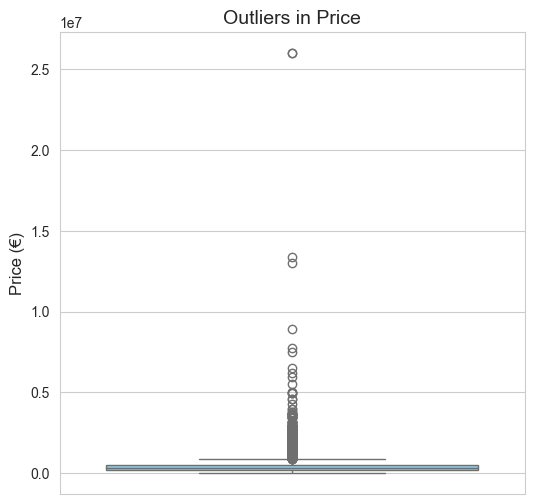

In [109]:
plt.figure(figsize=(6,6))
sns.boxplot(y=df["Price"], color="skyblue")

plt.title("Outliers in Price")
plt.ylabel("Price (€)")

plt.show()

### Outliers in Key Numerical Variables

Boxplots are used to visualize potential outliers in important numerical variables such as **Living Area**, **price per m²**, and **Surface of the land**.

Real estate datasets often contain extreme values because some properties are significantly larger or located on much bigger land plots than others. These values appear as points outside the main box in the boxplots.

Most extreme values were already treated during the data cleaning phase (for example unrealistic living area values or extremely large garden sizes). The remaining outliers therefore likely represent legitimate properties such as very large houses or properties located on large plots of land.

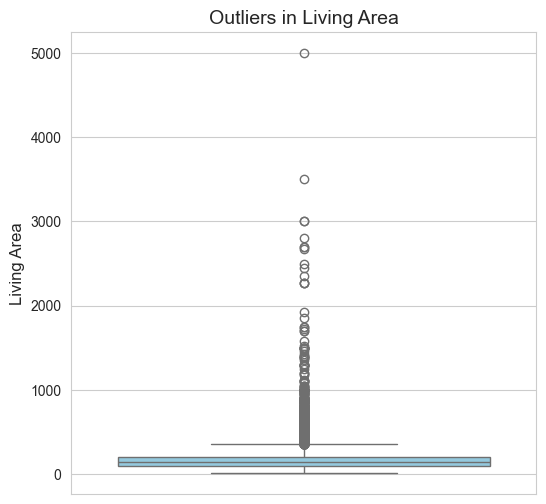

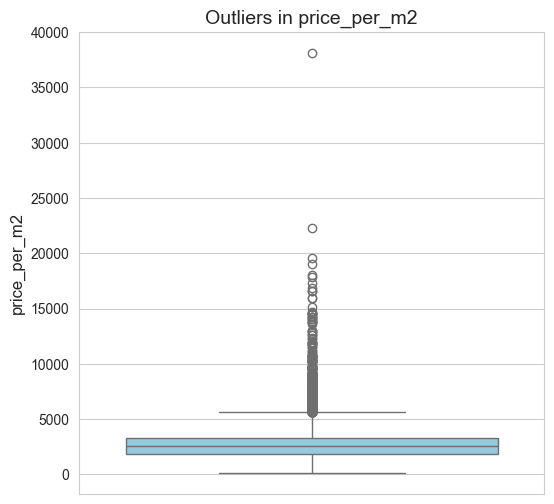

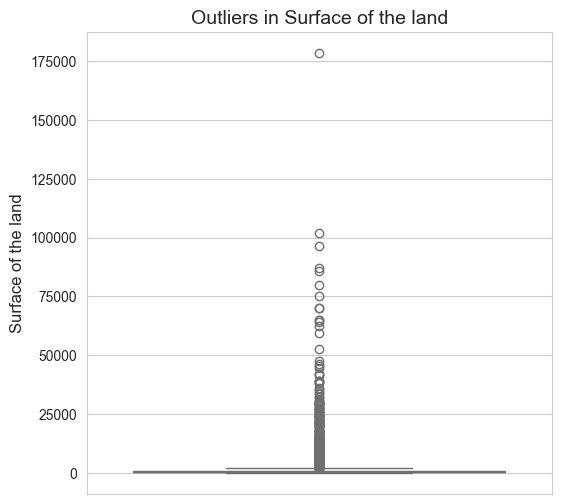

In [110]:
cols_to_check = ["Living Area", "price_per_m2", "Surface of the land"]

for col in cols_to_check:
    plt.figure(figsize=(6,6))
    sns.boxplot(y=df[col], color="skyblue")

    plt.title(f"Outliers in {col}")
    plt.ylabel(col)

    plt.show()

### Price Distribution by Region

This boxplot compares property prices across the three Belgian regions: **Brussels, Flanders, and Wallonia**.

The visualization highlights differences in median prices between regions and shows the presence of high-value outliers. These differences can be explained by variations in demand, population density, and economic activity across regions.

For example, Brussels often shows higher price levels because it is the capital city and has a high demand for housing.

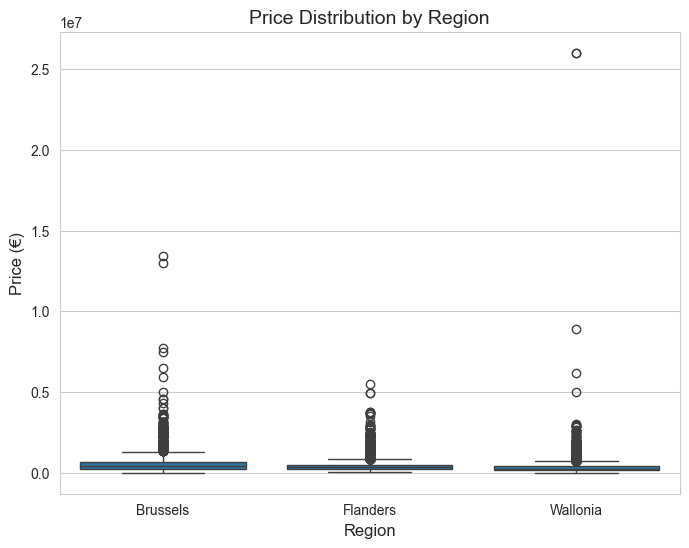

In [111]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="Region", y="Price")

plt.title("Price Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Price (€)")

plt.show()

### Price vs Living Area (Scatter Plot)

This scatter plot illustrates the relationship between **Living Area** and **Price**. A positive relationship can be observed, meaning that properties with larger living areas generally tend to have higher prices.

However, the spread of points shows that price is not determined by size alone. Other factors such as location, property condition, and additional features can also influence the final price.

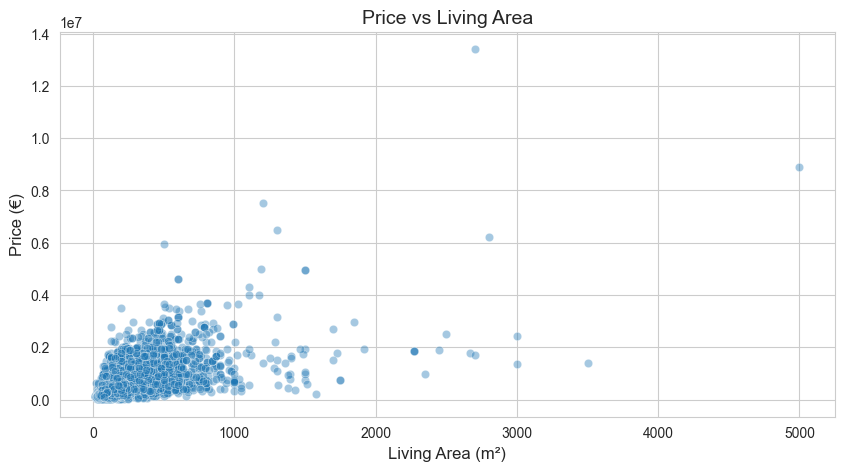

In [112]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x="Living Area", y="Price", alpha=0.4)
plt.title("Price vs Living Area")
plt.xlabel("Living Area (m²)")
plt.ylabel("Price (€)")
plt.show()

### Price vs Price per m² (Scatter Plot)

This plot shows the relationship between **price per square meter** and the total property price. Price per m² helps normalize price by property size, making it easier to compare properties of different sizes.

Higher price per m² values often reflect premium locations, higher-quality properties, or properties located in areas with strong demand.

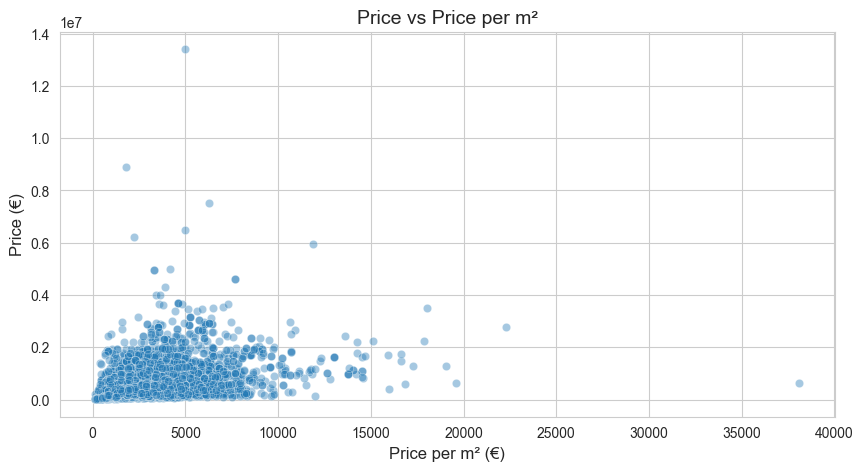

In [113]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x="price_per_m2", y="Price", alpha=0.4)
plt.title("Price vs Price per m²")
plt.xlabel("Price per m² (€)")
plt.ylabel("Price (€)")
plt.show()

### Which variables would you delete and why ?

## Already deleted 
1. surface area of the plot : which i already deleted as there was literally no data scrapped for  it 
2. open fire : this column contained a very high percentage of missing values about more than 90 percent  therefore decided to delete it. 

## can be deleted as it would have no big impact 

Based on the correlation matrix, some variables provide limited useful information for price analysis.
### Variables Could Be Deleted and Why?

Some variables may provide limited additional information for price analysis.

First, variables such as **Furnished** and **Fully equipped kitchen** show very weak correlations with price. These binary amenities may influence the attractiveness of a property but do not strongly explain price variations compared to structural features.

Second, **Zip Code** can be removed because it acts mainly as an identifier rather than a meaningful numerical variable. Although it represents location, its numerical value does not represent a quantitative relationship. Location is better captured through variables such as **Municipality** or **Region**.

Third, some variables capture similar information. For example, **Garden Area** and **Surface of the land** are related because larger land plots often allow larger gardens. In such cases, keeping only one variable could simplify the dataset without losing much explanatory power.

Overall, this suggests that **structural characteristics such as living area, number of rooms, and land size are much stronger drivers of property price than optional amenities**.

### Represent the number of properties according to their surface using a histogram.

### Distribution of Properties by Living Area

The following histogram shows the distribution of properties according to their living area.  
Most properties fall within a moderate size range, while very large properties are less common.  
This distribution is typical in real estate markets where medium-sized properties are the most frequently listed.

because most families consist of small number of people and they don't need bigger living areas therfore thats why mostly the distribution of property is between 100-250 m2.  

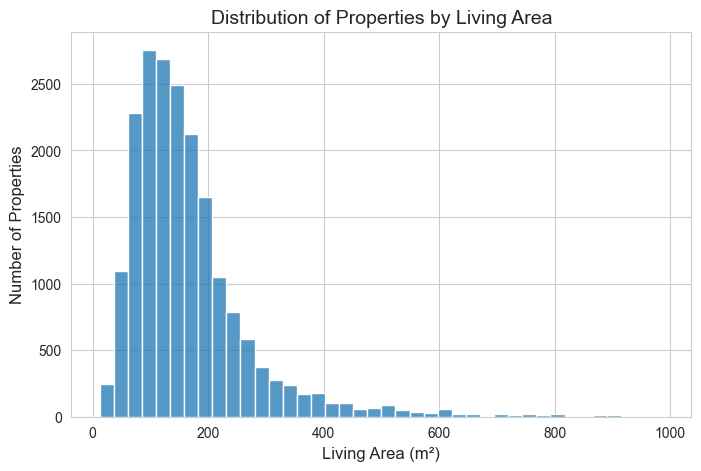

In [114]:
plt.figure(figsize=(8,5))

sns.histplot(df[df["Living Area"] < 1000]["Living Area"], bins=40)

plt.title("Distribution of Properties by Living Area")
plt.xlabel("Living Area (m²)")
plt.ylabel("Number of Properties")

plt.show()

In [115]:
jon= df[df["Living Area"] > 1000]["Living Area"].sort_values()
len(jon)

64

### Distribution of Properties by Land Surface

This histogram shows the distribution of properties based on the size of the land. Most properties have relatively small land surfaces, while a smaller number of properties are located on much larger plots.

The distribution is **right-skewed**, meaning that the majority of properties have modest land sizes, while a few properties with very large land surfaces create a long tail on the right side of the distribution.

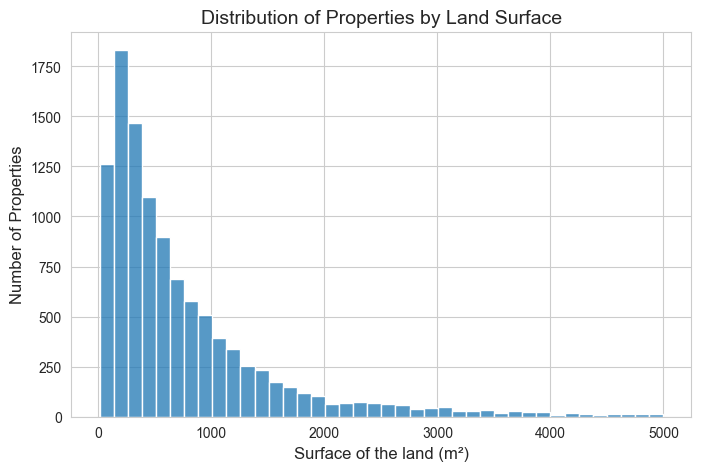

In [116]:
plt.figure(figsize=(8,5))

sns.histplot(df[df["Surface of the land"] < 5000]["Surface of the land"], bins=40)

plt.title("Distribution of Properties by Land Surface")
plt.xlabel("Surface of the land (m²)")
plt.ylabel("Number of Properties")

plt.show()
plt.show()

### Comparison between Living Area and Land Surface

Both distributions are right-skewed, meaning that most properties have relatively moderate sizes while a small number of properties have extremely large values.

The **living area** distribution is more concentrated, with most properties between roughly **80 m² and 200 m²**, which reflects the typical size of houses and apartments.

In contrast, **land surface** shows a much wider spread. While many properties have smaller plots, some properties are located on very large pieces of land, creating a longer tail in the distribution. This happens because houses can be built on very large plots, while apartments usually have little or no associated land.

### In your opinion, which 5 variables are the most important and why?

### In Your Opinion:

Based on the correlation analysis and domain knowledge of the real estate market, the five most important variables influencing property price are:
1. **Living Area** – The strongest driver of price since larger properties generally have higher values.
2. **Number of rooms** – Closely related to property size and usability.
3. **Municipality** – Represents the mrket value of location and its demand based on the location. 
4. **Surface of the land** – Larger land plots often increase the total value of a property.
5. **Building state** – The condition of a property affects renovation needs and therefore its market value.

These variables capture the **size, quality, and valuation of the property**, which are the main factors influencing real estate prices.

### Most Expensive Municipalities in Belgium

To identify the most expensive municipalities in Belgium, the dataset was grouped by **Municipality** and the following metrics were calculated:

- **Average price**
- **Median price**
- **Median price per square meter**
- **Number of listings**

To make the comparison more reliable, only municipalities with at least **10 listings** were kept. This avoids ranking municipalities based on only a few exceptional properties.

The municipalities were then sorted by **average price** in descending order to identify the most expensive locations.

In [117]:
df.groupby('Municipality').agg(
    avg_price= ('Price', 'mean'),
    median_price= ('Price', 'median'),
    price_per_m2= ('price_per_m2', 'median'), 
    count=('Price', 'count')
    ).query('count >= 10').sort_values('avg_price', ascending=False).head(10).round(2)

,avg_price,median_price,price_per_m2,count
Municipality,,,,
Knokke,1095939.02,795000.0,9112.90,41
Kraainem,1083945.00,1010000.0,4113.17,40
Sterrebeek,1022734.24,849000.0,4087.72,37
Eernegem,983500.00,347000.0,2211.54,14
Sint Pieters Woluwe,885895.60,695000.0,4062.50,182
Overijse,885336.36,645000.0,3407.64,44
Ukkel,870925.67,631000.0,4483.87,402
Knokke Heist,867344.55,819000.0,7869.46,55
Sint Genesius Rode,858824.56,685000.0,3406.25,57


/var/folders/z9/zqj9_h_x2999k870_htqk8rh0000gn/T/ipykernel_5188/2999696243.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


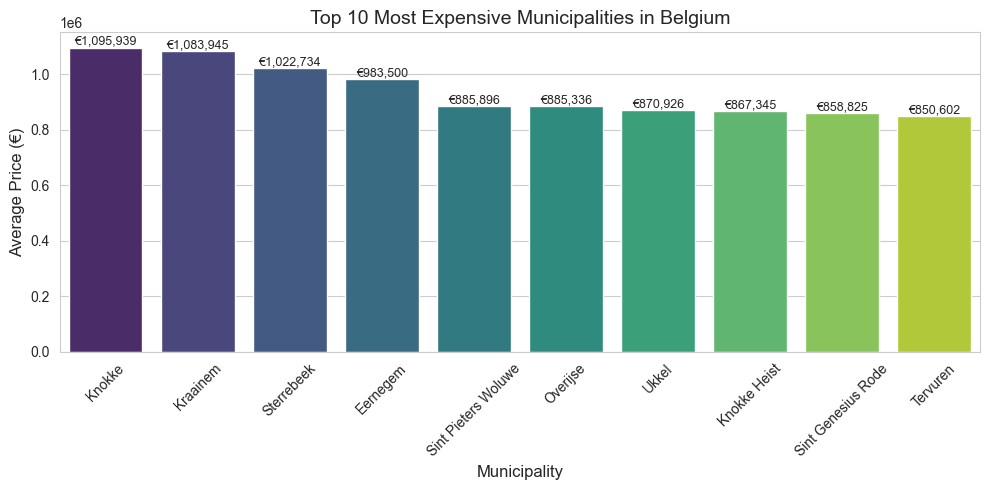

In [118]:
top_expensive_be = df.groupby("Municipality").agg(
    avg_price=("Price", "mean"),
    median_price=("Price", "median"),
    price_per_m2=("price_per_m2", "median"),
    count=("Price", "count")
).query("count >= 10").sort_values("avg_price", ascending=False).head(10).round(2)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_expensive_be.index,
    y=top_expensive_be["avg_price"],
    palette="viridis"
)

plt.title("Top 10 Most Expensive Municipalities in Belgium")
plt.ylabel("Average Price (€)")
plt.xlabel("Municipality")

plt.xticks(rotation=45)
plt.tight_layout()
for i, v in enumerate(top_expensive_be["avg_price"]):
    plt.text(i, v, f"€{v:,.0f}", ha="center", va="bottom", fontsize=9)
plt.show()

### Most Expensive Municipalities in Wallonia

To identify the most expensive municipalities in Wallonia, the dataset was first filtered to include only properties located in the **Wallonia** region.

The data was then grouped by municipality, and the **average price**, **median price**, **median price per square meter**, and **number of listings** were calculated.

Only municipalities with at least **10 listings** were kept in order to ensure more reliable comparisons.

In [119]:
df[df["Region"] == "Wallonia"].groupby("Municipality").agg(
    avg_price=("Price", "mean"),
    median_price=("Price", "median"),
    price_per_m2=("price_per_m2", "median"),
    count=("Price", "count")
).query("count >= 10").sort_values("avg_price", ascending=False).head(10).round(2)

,avg_price,median_price,price_per_m2,count
Municipality,,,,
La Hulpe,847470.59,575000.0,3027.78,17
Lasne,808061.61,720000.0,3077.08,49
Grez Doiceau,735802.09,445000.0,2875.00,43
Dinant,696001.39,248000.0,1591.45,71
Couillet,673745.00,207500.0,1474.82,20
Chaumont Gistoux,653253.42,685000.0,3095.72,26
Waterloo,645078.24,531250.0,3442.31,131
Genval,635826.09,540000.0,3396.90,23
Charleroi,631543.69,178950.0,1392.52,64


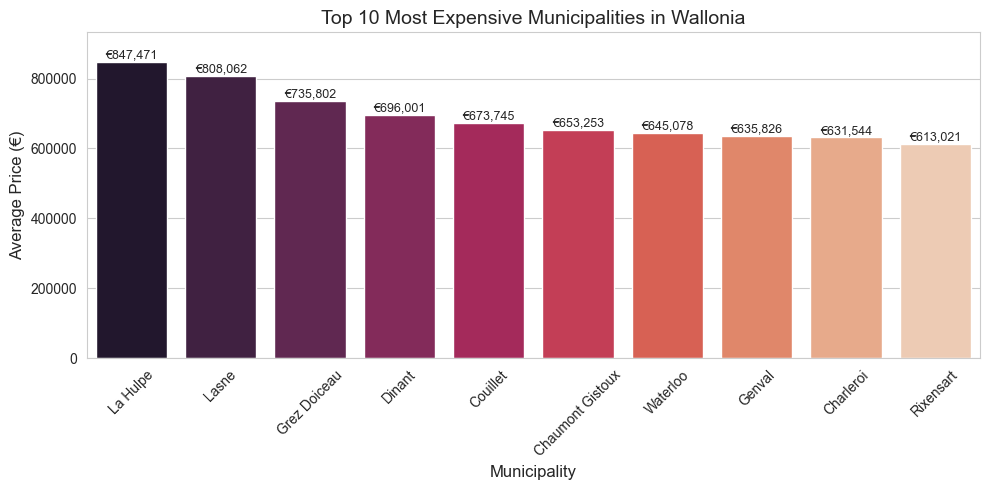

In [136]:
top_expensive_wallonia = df[df["Region"] == "Wallonia"].groupby("Municipality").agg(
    avg_price=("Price", "mean"),
    median_price=("Price", "median"),
    price_per_m2=("price_per_m2", "median"),
    count=("Price", "count")
).query("count >= 10").sort_values("avg_price", ascending=False).head(10).round(2)
plt.figure(figsize=(10,5))

sns.barplot(
    data=top_expensive_wallonia,
    x="Municipality",
    y="avg_price",
    hue="Municipality",
    palette="rocket",
    legend=False
)

for i, v in enumerate(top_expensive_wallonia["avg_price"]):
    plt.text(i, v + 10000, f"€{v:,.0f}", ha="center", fontsize=9)

plt.title("Top 10 Most Expensive Municipalities in Wallonia")
plt.ylabel("Average Price (€)")
plt.xlabel("Municipality")

plt.xticks(rotation=45)

plt.ticklabel_format(style='plain', axis='y')

plt.ylim(0, top_expensive_wallonia["avg_price"].max() * 1.10)

plt.tight_layout()
plt.show()

### Most Expensive Municipalities in Flanders

To identify the most expensive municipalities in Flanders, the dataset was filtered to include only properties located in the **Flanders** region.

The municipalities were then grouped and ranked according to their **average property price**. In addition, the **median price**, **median price per square meter**, and **number of listings** were calculated.

A minimum of **10 listings per municipality** was required to avoid unreliable rankings caused by very small sample sizes.

In [121]:
df[df["Region"] == "Flanders"].groupby("Municipality").agg(
    avg_price=("Price", "mean"),
    median_price=("Price", "median"),
    price_per_m2=("price_per_m2", "median"),
    count=("Price", "count")
).query("count >= 10").sort_values("avg_price", ascending=False).head(10).round(2)

,avg_price,median_price,price_per_m2,count
Municipality,,,,
Knokke,1095939.02,795000.0,9112.90,41
Kraainem,1083945.00,1010000.0,4113.17,40
Sterrebeek,1022734.24,849000.0,4087.72,37
Eernegem,983500.00,347000.0,2211.54,14
Overijse,885336.36,645000.0,3407.64,44
Knokke Heist,867344.55,819000.0,7869.46,55
Sint Genesius Rode,858824.56,685000.0,3406.25,57
Tervuren,850601.56,696000.0,3500.00,32
Schilde,784806.00,643130.5,3452.68,14


/var/folders/z9/zqj9_h_x2999k870_htqk8rh0000gn/T/ipykernel_5188/3391307363.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


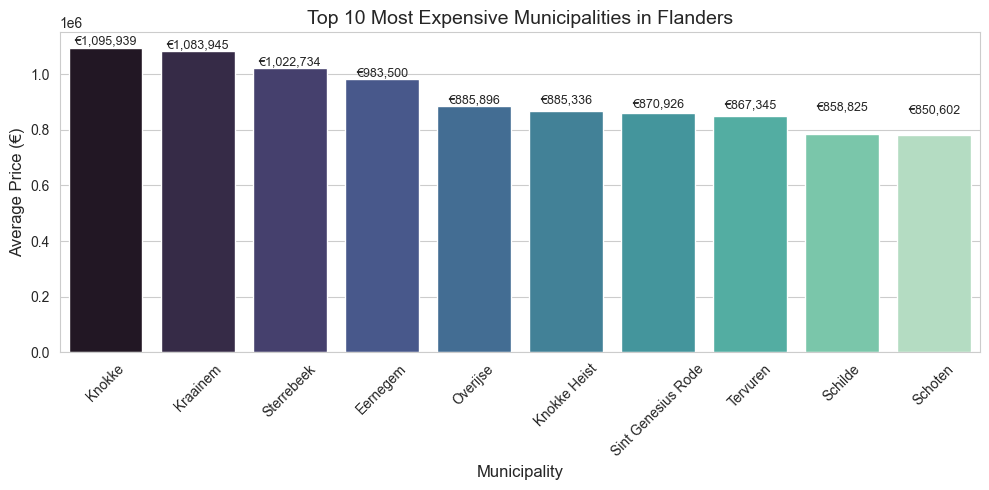

In [122]:
top_expensive_flanders = df[df["Region"] == "Flanders"].groupby("Municipality").agg(
    avg_price=("Price", "mean"),
    median_price=("Price", "median"),
    price_per_m2=("price_per_m2", "median"),
    count=("Price", "count")
).query("count >= 10").sort_values("avg_price", ascending=False).head(10).round(2)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_expensive_flanders.index,
    y=top_expensive_flanders["avg_price"],
    palette="mako"
)

plt.title("Top 10 Most Expensive Municipalities in Flanders")
plt.ylabel("Average Price (€)")
plt.xlabel("Municipality")

plt.xticks(rotation=45)
plt.tight_layout()
for i, v in enumerate(top_expensive_be["avg_price"]):
    plt.text(i, v, f"€{v:,.0f}", ha="center", va="bottom", fontsize=9)
plt.show()

### Least Expensive Municipalities in Belgium

To identify the least expensive municipalities in Belgium, the same grouped municipality data was used, but this time sorted in **ascending order** based on the **average price**.

As before, only municipalities with at least **10 listings** were included to make the comparison more robust and avoid distortions caused by very small sample sizes.

In [123]:
df.groupby("Municipality").agg(
    avg_price=("Price", "mean"),
    median_price=("Price", "median"),
    price_per_m2=("price_per_m2", "median"),
    count=("Price", "count")
).query("count >= 10").sort_values("avg_price", ascending=True).head(10).round(2)

,avg_price,median_price,price_per_m2,count
Municipality,,,,
Blaimont,86113.64,66750.0,1574.07,22
Hastiere Lavaux,91721.43,86950.0,1449.17,14
Marchienne Au Pont,144620.71,154499.5,967.57,24
Colfontaine,149620.83,144500.0,1032.11,24
Erquelinnes,170312.31,165500.0,1110.78,16
Engis,170866.67,169000.0,1408.33,15
Jemappes,172003.57,165000.0,1205.61,14
Hastiere,177671.43,149000.0,1807.26,35
Ougree,177786.21,188000.0,1594.89,29


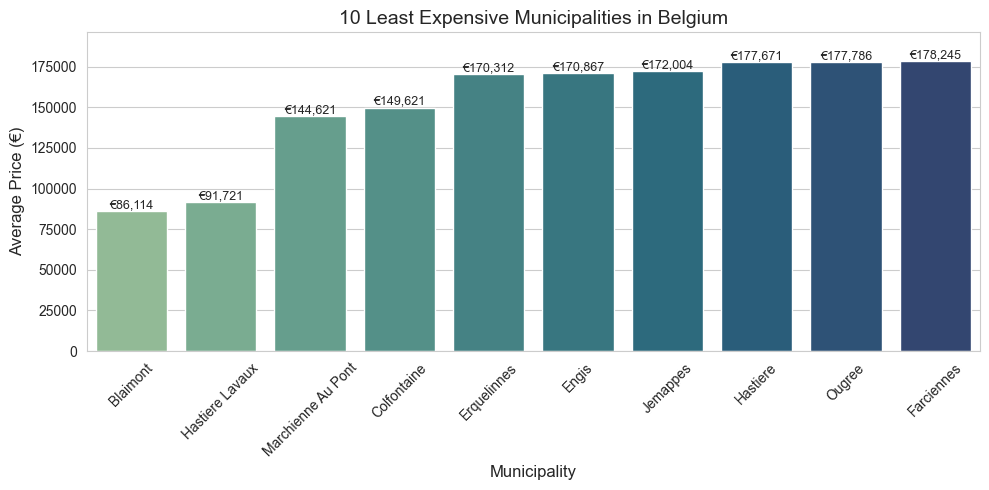

In [137]:
least_expensive_be = df.groupby("Municipality").agg(
    avg_price=("Price", "mean"),
    median_price=("Price", "median"),
    price_per_m2=("price_per_m2", "median"),
    count=("Price", "count")
).query("count >= 10").sort_values("avg_price", ascending=True).head(10).round(2)

plt.figure(figsize=(10,5))

sns.barplot(
    x=least_expensive_be.index,
    y=least_expensive_be["avg_price"],
    hue=least_expensive_be.index,   # fixes seaborn warning
    palette="crest",
    legend=False
)

plt.title("10 Least Expensive Municipalities in Belgium")
plt.ylabel("Average Price (€)")
plt.xlabel("Municipality")

plt.xticks(rotation=45)

# Remove scientific notation
plt.ticklabel_format(style='plain', axis='y')

# Add value labels
for i, v in enumerate(least_expensive_be["avg_price"]):
    plt.text(i, v + 2000, f"€{v:,.0f}", ha="center", fontsize=9)

# Add some space above bars
plt.ylim(0, least_expensive_be["avg_price"].max() * 1.10)

plt.tight_layout()
plt.show()

### Least Expensive Municipalities in Wallonia

To identify the least expensive municipalities in Wallonia, the dataset was filtered for the **Wallonia** region and grouped by municipality.

The municipalities were then sorted in **ascending order** based on their **average price**. Only municipalities with at least **10 listings** were kept to ensure that the results are based on a sufficient number of observations.

In [125]:
df[df["Region"] == "Wallonia"].groupby("Municipality").agg(
    avg_price=("Price", "mean"),
    median_price=("Price", "median"),
    price_per_m2=("price_per_m2", "median"),
    count=("Price", "count")
).query("count >= 10").sort_values("avg_price", ascending=True).head(10).round(2)

,avg_price,median_price,price_per_m2,count
Municipality,,,,
Blaimont,86113.64,66750.0,1574.07,22
Hastiere Lavaux,91721.43,86950.0,1449.17,14
Marchienne Au Pont,144620.71,154499.5,967.57,24
Colfontaine,149620.83,144500.0,1032.11,24
Erquelinnes,170312.31,165500.0,1110.78,16
Engis,170866.67,169000.0,1408.33,15
Jemappes,172003.57,165000.0,1205.61,14
Hastiere,177671.43,149000.0,1807.26,35
Ougree,177786.21,188000.0,1594.89,29


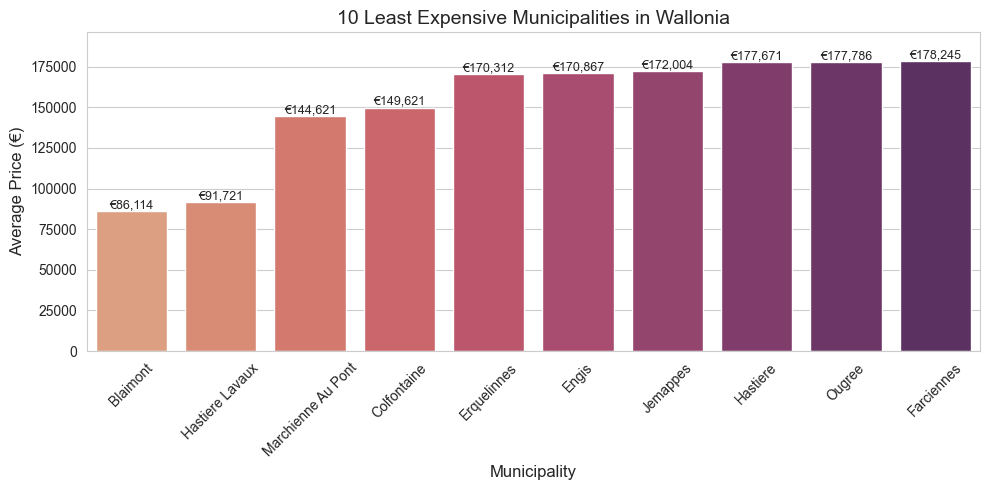

In [138]:
least_expensive_wallonia = df[df["Region"] == "Wallonia"].groupby("Municipality").agg(
    avg_price=("Price", "mean"),
    median_price=("Price", "median"),
    price_per_m2=("price_per_m2", "median"),
    count=("Price", "count")
).query("count >= 10").sort_values("avg_price", ascending=True).head(10).round(2)

plt.figure(figsize=(10,5))

sns.barplot(
    x=least_expensive_wallonia.index,
    y=least_expensive_wallonia["avg_price"],
    hue=least_expensive_wallonia.index,
    palette="flare",
    legend=False
)

plt.title("10 Least Expensive Municipalities in Wallonia")
plt.ylabel("Average Price (€)")
plt.xlabel("Municipality")
plt.xticks(rotation=45)

plt.ticklabel_format(style="plain", axis="y")

for i, v in enumerate(least_expensive_wallonia["avg_price"]):
    plt.text(i, v + 2000, f"€{v:,.0f}", ha="center", fontsize=9)

plt.ylim(0, least_expensive_wallonia["avg_price"].max() * 1.10)

plt.tight_layout()
plt.show()

### Least Expensive Municipalities in Flanders

To identify the least expensive municipalities in Flanders, the dataset was filtered for the **Flanders** region and grouped by municipality.

The municipalities were then ranked in **ascending order** according to their **average property price**. A minimum threshold of **10 listings** per municipality was applied to improve the reliability of the ranking.

In [127]:
df[df["Region"] == "Flanders"].groupby("Municipality").agg(
    avg_price=("Price", "mean"),
    median_price=("Price", "median"),
    price_per_m2=("price_per_m2", "median"),
    count=("Price", "count")
).query("count >= 10").sort_values("avg_price", ascending=True).head(10).round(2)

,avg_price,median_price,price_per_m2,count
Municipality,,,,
Wervik,199232.25,192500.0,1059.02,28
Gingelom,216133.33,199000.0,1206.06,15
Rekkem,239375.00,212000.0,1776.76,16
Middelkerke,248287.50,239000.0,4047.62,24
Zutendaal,255461.80,252000.0,2226.89,20
Deurne,260210.99,235000.0,2499.48,91
Borgerhout,261494.44,232000.0,2509.04,36
Moorslede,261833.33,172000.0,1687.50,12
Zellik,271876.76,254500.0,2760.88,34


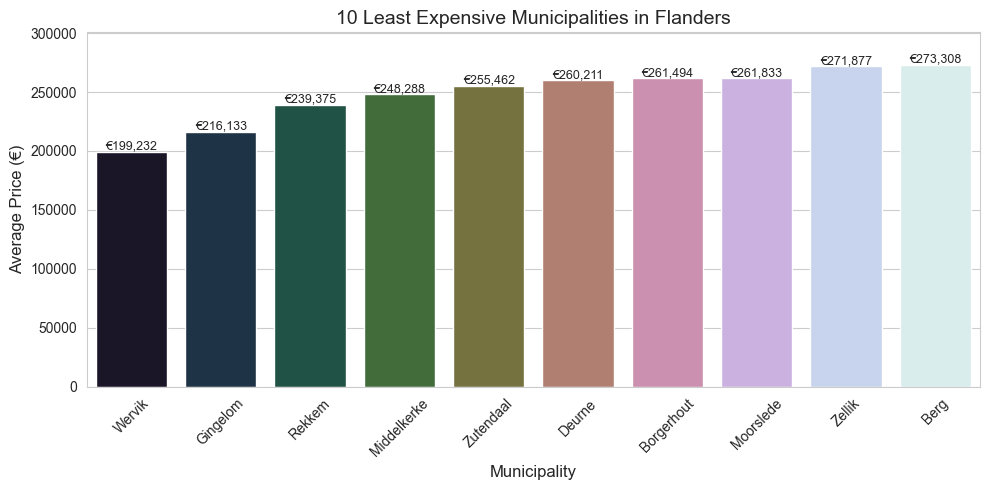

In [139]:
least_expensive_flanders = df[df["Region"] == "Flanders"].groupby("Municipality").agg(
    avg_price=("Price", "mean"),
    median_price=("Price", "median"),
    price_per_m2=("price_per_m2", "median"),
    count=("Price", "count")
).query("count >= 10").sort_values("avg_price", ascending=True).head(10).round(2)

plt.figure(figsize=(10,5))

sns.barplot(
    x=least_expensive_flanders.index,
    y=least_expensive_flanders["avg_price"],
    hue=least_expensive_flanders.index,   # fixes seaborn warning
    palette="cubehelix",
    legend=False
)

plt.title("10 Least Expensive Municipalities in Flanders")
plt.ylabel("Average Price (€)")
plt.xlabel("Municipality")

plt.xticks(rotation=45)

# remove scientific notation
plt.ticklabel_format(style="plain", axis="y")

# add labels above bars
for i, v in enumerate(least_expensive_flanders["avg_price"]):
    plt.text(i, v + 2000, f"€{v:,.0f}", ha="center", fontsize=9)

# add space above bars
plt.ylim(0, least_expensive_flanders["avg_price"].max() * 1.10)

plt.tight_layout()
plt.show()